## Surface climate, radiative and temperature ersponces to the experiments

In [1]:
import numpy as np
import xarray as xr
import pandas as pd
import cftime
import calendar
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
import matplotlib.path as mpath
from matplotlib.offsetbox import OffsetImage, AnnotationBbox
import matplotlib.ticker as mticker
from matplotlib.colors import TwoSlopeNorm
from matplotlib.patches import Rectangle
import matplotlib.dates as mdates
import imageio
import os
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import datetime #import datetime
from glob import glob
from scipy import signal

In [ ]:
# dask
import dask
import dask.array as da
import distributed
from dask.distributed import Client

client = Client()
client

Connection method: Cluster object,Cluster type: distributed.LocalCluster
Dashboard: http://127.0.0.1:8787/status,
Dashboard: http://127.0.0.1:8787/status,Workers: 8
Total threads: 32,Total memory: 35.00 GiB
Status: running,Using processes: True
Comm: tcp://127.0.0.1:37599,Workers: 0
Dashboard: http://127.0.0.1:8787/status,Total threads: 0
Started: Just now,Total memory: 0 B
Comm: tcp://127.0.0.1:37405,Total threads: 4
Dashboard: http://127.0.0.1:43647/status,Memory: 4.38 GiB
Nanny: tcp://127.0.0.1:36323,


2026-01-06 11:33:35,142 - distributed.nanny - WARNING - Restarting worker


In [5]:
path_atm = "/nird/datapeak/NS1004K/elihho/NHIST_tropochem_250916/atm/hist"
ds_19 = xr.open_mfdataset(f"{path_atm}/NHIST_tropstratchem_f09_tn14_20250917_1975_2014.cam.h0.*.nc", combine="by_coords", parallel=True)

Exception ignored in: <function CachingFileManager.__del__ at 0x7fc93850b240>
Traceback (most recent call last):
  File "/nird/home/elihho/miniconda3/envs/master/lib/python3.13/site-packages/xarray/backends/file_manager.py", line 250, in __del__
    self.close(needs_lock=False)
  File "/nird/home/elihho/miniconda3/envs/master/lib/python3.13/site-packages/xarray/backends/file_manager.py", line 234, in close
    file.close()
  File "src/netCDF4/_netCDF4.pyx", line 2669, in netCDF4._netCDF4.Dataset.close
  File "src/netCDF4/_netCDF4.pyx", line 2636, in netCDF4._netCDF4.Dataset._close
  File "src/netCDF4/_netCDF4.pyx", line 2164, in netCDF4._netCDF4._ensure_nc_success
RuntimeError: NetCDF: Not a valid ID


In [6]:
path_atm_22 = "/nird/datapeak/NS1004K/elihho/NHIST_tropstratchem_20251125_pinatubo10Tg22_e01/atm/hist"
ds_22 = xr.open_mfdataset(f"{path_atm_22}/NHIST_tropstratchem_f09_tn14_20251125_Pinatubo10Tg22_01.cam.h0.*.nc", combine="by_coords", parallel=True)

Exception ignored in: <function CachingFileManager.__del__ at 0x7fc93850b240>
Traceback (most recent call last):
  File "/nird/home/elihho/miniconda3/envs/master/lib/python3.13/site-packages/xarray/backends/file_manager.py", line 250, in __del__
    self.close(needs_lock=False)
  File "/nird/home/elihho/miniconda3/envs/master/lib/python3.13/site-packages/xarray/backends/file_manager.py", line 234, in close
    file.close()
  File "src/netCDF4/_netCDF4.pyx", line 2669, in netCDF4._netCDF4.Dataset.close
  File "src/netCDF4/_netCDF4.pyx", line 2636, in netCDF4._netCDF4.Dataset._close
  File "src/netCDF4/_netCDF4.pyx", line 2164, in netCDF4._netCDF4._ensure_nc_success
RuntimeError: NetCDF: Not a valid ID


In [9]:
path_atm_19_c =  "/nird/datapeak/NS1004K/elihho/NHIST_tropstratchem_20251128_pinatubo10Tg19_e01/atm/hist"
ds_19_c = xr.open_mfdataset(f"{path_atm_19_c}/NHIST_tropstratchem_f09_tn14_20251128_Pinatubo10Tg19_01.cam.h0.*.nc", combine="by_coords", parallel=True)

Exception ignored in: <function CachingFileManager.__del__ at 0x7fdc6a9f2f20>
Traceback (most recent call last):
  File "/nird/home/elihho/miniconda3/envs/master/lib/python3.13/site-packages/xarray/backends/file_manager.py", line 250, in __del__
    self.close(needs_lock=False)
  File "/nird/home/elihho/miniconda3/envs/master/lib/python3.13/site-packages/xarray/backends/file_manager.py", line 234, in close
    file.close()
  File "src/netCDF4/_netCDF4.pyx", line 2669, in netCDF4._netCDF4.Dataset.close
  File "src/netCDF4/_netCDF4.pyx", line 2636, in netCDF4._netCDF4.Dataset._close
  File "src/netCDF4/_netCDF4.pyx", line 2164, in netCDF4._netCDF4._ensure_nc_success
RuntimeError: NetCDF: Not a valid ID


In [10]:
path_atm_24 = "/nird/datapeak/NS1004K/elihho/NHIST_tropstratchem_20251129_pinatubo17Tg24_e01/atm/hist"
ds_24 = xr.open_mfdataset(f"{path_atm_24}/NHIST_tropstratchem_f09_tn14_20251129_Pinatubo17Tg24_01.cam.h0.*.nc", combine="by_coords", parallel=True)

Exception ignored in: <function CachingFileManager.__del__ at 0x7fdc6a9f2f20>
Traceback (most recent call last):
  File "/nird/home/elihho/miniconda3/envs/master/lib/python3.13/site-packages/xarray/backends/file_manager.py", line 250, in __del__
    self.close(needs_lock=False)
  File "/nird/home/elihho/miniconda3/envs/master/lib/python3.13/site-packages/xarray/backends/file_manager.py", line 234, in close
    file.close()
  File "src/netCDF4/_netCDF4.pyx", line 2669, in netCDF4._netCDF4.Dataset.close
  File "src/netCDF4/_netCDF4.pyx", line 2636, in netCDF4._netCDF4.Dataset._close
  File "src/netCDF4/_netCDF4.pyx", line 2164, in netCDF4._netCDF4._ensure_nc_success
RuntimeError: NetCDF: Not a valid ID


In [11]:
path_atm_1825 = "/nird/datapeak/NS1004K/elihho/NHIST_tropstratchem_20251204_pinatubo10Tg18_25_e01/atm/hist"
ds_1825 = xr.open_mfdataset(f"{path_atm_1825}/NHIST_tropstratchem_f09_tn14_20251204_Pinatubo10Tg18_25_01.cam.h0.*.nc", combine="by_coords", parallel=True)

Exception ignored in: <function CachingFileManager.__del__ at 0x7fdc6a9f2f20>
Traceback (most recent call last):
  File "/nird/home/elihho/miniconda3/envs/master/lib/python3.13/site-packages/xarray/backends/file_manager.py", line 250, in __del__
    self.close(needs_lock=False)
  File "/nird/home/elihho/miniconda3/envs/master/lib/python3.13/site-packages/xarray/backends/file_manager.py", line 234, in close
    file.close()
  File "src/netCDF4/_netCDF4.pyx", line 2669, in netCDF4._netCDF4.Dataset.close
  File "src/netCDF4/_netCDF4.pyx", line 2636, in netCDF4._netCDF4.Dataset._close
  File "src/netCDF4/_netCDF4.pyx", line 2164, in netCDF4._netCDF4._ensure_nc_success
RuntimeError: NetCDF: Not a valid ID


In [12]:
path_atm_1825_17tg = "/nird/datapeak/NS1004K/elihho/NHIST_tropstratchem_20251207_pinatubo17Tg18_25_e01/atm/hist"
ds_1825_17tg = xr.open_mfdataset(f"{path_atm_1825_17tg}/NHIST_tropstratchem_f09_tn14_20251207_Pinatubo17Tg18_25_01.cam.h0.*.nc", combine="by_coords", parallel=True)

Exception ignored in: <function CachingFileManager.__del__ at 0x7fdc6a9f2f20>
Traceback (most recent call last):
  File "/nird/home/elihho/miniconda3/envs/master/lib/python3.13/site-packages/xarray/backends/file_manager.py", line 250, in __del__
    self.close(needs_lock=False)
  File "/nird/home/elihho/miniconda3/envs/master/lib/python3.13/site-packages/xarray/backends/file_manager.py", line 234, in close
    file.close()
  File "src/netCDF4/_netCDF4.pyx", line 2669, in netCDF4._netCDF4.Dataset.close
  File "src/netCDF4/_netCDF4.pyx", line 2636, in netCDF4._netCDF4.Dataset._close
  File "src/netCDF4/_netCDF4.pyx", line 2164, in netCDF4._netCDF4._ensure_nc_success
RuntimeError: NetCDF: Not a valid ID


In [13]:
path_atm_1tg = "/nird/datapeak/NS1004K/elihho/NHIST_tropstratchem_20251210_pinatubo1Tg19_e01/atm/hist"
ds_1tg = xr.open_mfdataset(f"{path_atm_1tg}/NHIST_tropstratchem_f09_tn14_20251210_Pinatubo1Tg19_01.cam.h0.*.nc", combine="by_coords", parallel=True)

Exception ignored in: <function CachingFileManager.__del__ at 0x7fdc6a9f2f20>
Traceback (most recent call last):
  File "/nird/home/elihho/miniconda3/envs/master/lib/python3.13/site-packages/xarray/backends/file_manager.py", line 250, in __del__
    self.close(needs_lock=False)
  File "/nird/home/elihho/miniconda3/envs/master/lib/python3.13/site-packages/xarray/backends/file_manager.py", line 234, in close
    file.close()
  File "src/netCDF4/_netCDF4.pyx", line 2669, in netCDF4._netCDF4.Dataset.close
  File "src/netCDF4/_netCDF4.pyx", line 2636, in netCDF4._netCDF4.Dataset._close
  File "src/netCDF4/_netCDF4.pyx", line 2164, in netCDF4._netCDF4._ensure_nc_success
RuntimeError: NetCDF: Not a valid ID


In [29]:
path_atm_1pr = "/nird/datapeak/NS1004K/elihho/NHIST_tropstratchem_20251223_pinatubo10Tg_1pr/atm/hist"
ds_1pr = xr.open_mfdataset(f"{path_atm_1pr}/NHIST_tropstratchem_f09_tn14_20251223_Pinatubo10Tg19_1pr.cam.h0.*.nc", combine="by_coords", parallel=True)

In [14]:
client.close()

HDF5: infinite loop closing library
      L,T_top,P,P,Z,FD,VL,VL,PL,E,E,E,E,E,E,E,E,E,E,E,E,E,E,E,E,E,E,E,E,E,E,E,E,E,E,E,E,E,E,E,E,E,E,E,E,E,E,E,E,E,E,E,E,E,E,E,E,E,E,E,E,E,E,E,E,E,E,E,E,E,E,E,E,E,E,E,E,E,E,E,E,E,E,E,E,E,E,E,E,E,E,E,E,E,E,E,E,E,E,E,E,E,E,E


In [15]:
def shift_one_month_back(t):
    if t.month == 1:
        return cftime.DatetimeNoLeap(t.year - 1, 12, t.day, t.hour, t.minute, t.second)
    else:
        return cftime.DatetimeNoLeap(t.year, t.month - 1, t.day, t.hour, t.minute, t.second)

shifted_time = np.array([shift_one_month_back(t) for t in ds_19['time'].values])
ds_19 = ds_19.assign_coords(time=shifted_time)

shifted_time = np.array([shift_one_month_back(t) for t in ds_22['time'].values])
ds_22 = ds_22.assign_coords(time=shifted_time)

shifted_time = np.array([shift_one_month_back(t) for t in ds_19_c['time'].values])
ds_19_c = ds_19_c.assign_coords(time=shifted_time)

shifted_time = np.array([shift_one_month_back(t) for t in ds_24['time'].values])
ds_24 = ds_24.assign_coords(time=shifted_time)

shifted_time = np.array([shift_one_month_back(t) for t in ds_1825['time'].values])
ds_1825 = ds_1825.assign_coords(time=shifted_time)

shifted_time = np.array([shift_one_month_back(t) for t in ds_1825_17tg['time'].values])
ds_1825_17tg = ds_1825_17tg.assign_coords(time=shifted_time)

shifted_time = np.array([shift_one_month_back(t) for t in ds_1tg['time'].values])
ds_1tg = ds_1tg.assign_coords(time=shifted_time)

In [30]:
shifted_time = np.array([shift_one_month_back(t) for t in ds_1pr['time'].values])
ds_1pr = ds_1pr.assign_coords(time=shifted_time)

In [31]:
lat = ds_19["lat"]
weighted_lat = np.cos(np.deg2rad(lat))
lat_22 = ds_22["lat"]
weighted_lat_22 = np.cos(np.deg2rad(lat_22))
lat_19_c = ds_19_c["lat"]
weighted_lat_19_c = np.cos(np.deg2rad(lat_19_c))
lat_24 = ds_24["lat"]
weighted_lat_24 = np.cos(np.deg2rad(lat_24))
lat_1825 = ds_1825["lat"]
weighted_lat_1825 = np.cos(np.deg2rad(lat_1825))
lat_1825_17tg = ds_1825_17tg["lat"]
weighted_lat_1825_17tg = np.cos(np.deg2rad(lat_1825_17tg))
lat_1tg = ds_1tg["lat"]
weighted_lat_1tg = np.cos(np.deg2rad(lat_1tg))
lat_1pr = ds_1pr["lat"]
weighted_lat_1pr = np.cos(np.deg2rad(lat_1pr))

In [17]:
temp_ctrl = ds_19["T"]   # long baseline run
baseline = temp_ctrl.sel(time=slice("1976-01", "1981-12"))
base = baseline.groupby("time.month").mean("time")

In [18]:
def plot_temp_anomaly_lat_time(
    ds,
    base_clim,
    lev=50,
    plot_period=("1991-01-01", "1996-01-01"),
    eruption_time=cftime.DatetimeNoLeap(1991, 6, 15),
    lat_marker=15,
    ax=None,
    cmap="RdYlBu_r",
    title=None,
    add_colorbar=True,
):

    temp = ds["T"]
    temp_anom = temp.groupby("time.month") - base_clim

    temp_sel = temp_anom.sel(time=slice(*plot_period))
    temp_sel = temp_sel.sel(lev=lev, method="nearest")
    temp_lat_time = temp_sel.mean(dim="lon")

    if ax is None:
        fig, ax = plt.subplots(figsize=(7, 5))

    p = temp_lat_time.T.plot(
        ax=ax,
        x="time",
        y="lat",
        cmap=cmap,
        add_colorbar=add_colorbar,
        cbar_kwargs={"label": "Temperature anomaly (K)"} if add_colorbar else None,
    )

    if eruption_time is not None:
        ax.plot(
            eruption_time,
            lat_marker,
            marker="^",
            color="red",
            markersize=9,
            zorder=5,
        )

    ax.set_xlabel("Time")
    ax.set_ylabel("Latitude")

    if title:
        ax.set_title(title)

    return ax



<Axes: title={'center': 'Temperatur anomaly at ~50hPa, all eruptions in: 10Tg SO2, 19km'}, xlabel='Time', ylabel='Latitude'>

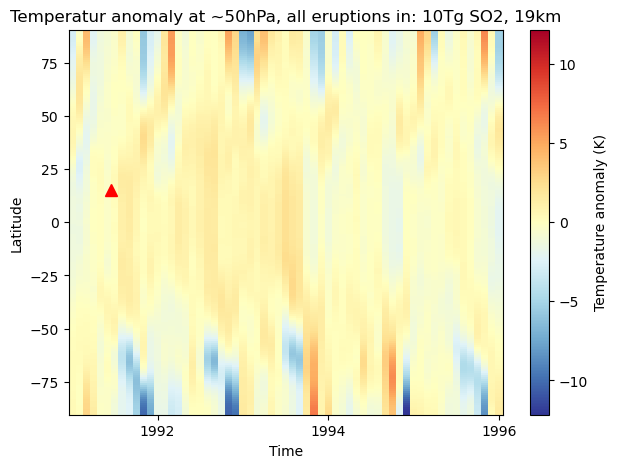

In [19]:
plot_temp_anomaly_lat_time(ds_19, base_clim = base, title="Temperatur anomaly at ~50hPa, all eruptions in: 10Tg SO2, 19km")

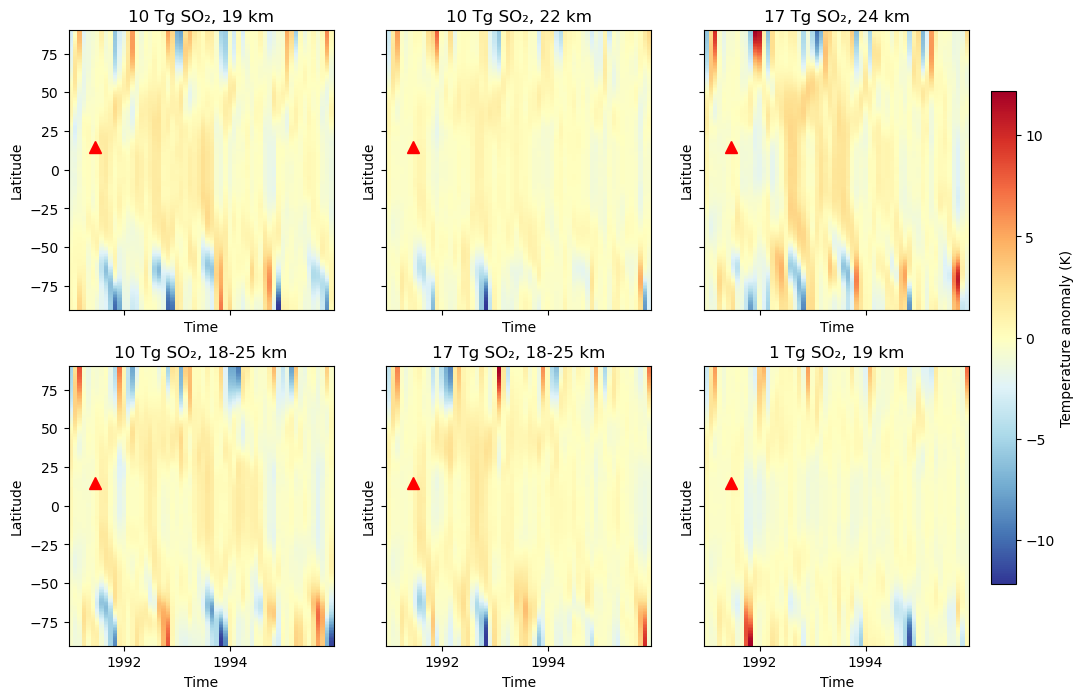

In [20]:
fig, axs = plt.subplots(2, 3, figsize=(14, 8), sharex=True, sharey=True)

datasets = [ds_19, ds_22, ds_24, ds_1825, ds_1825_17tg, ds_1tg]
titles = [
    "10 Tg SO₂, 19 km",
    "10 Tg SO₂, 22 km",
    "17 Tg SO₂, 24 km",
    "10 Tg SO₂, 18-25 km",
    "17 Tg SO₂, 18-25 km",
    "1 Tg SO₂, 19 km"
]

for ax, ds, title in zip(axs.flat, datasets, titles):
    plot_temp_anomaly_lat_time(
        ds,
        base,
        lev=50,
        ax=ax,
        add_colorbar=False,
        title=title,
    )

fig.colorbar(
    axs.flat[0].collections[0],
    ax=axs,
    label="Temperature anomaly (K)",
    shrink=0.8,
    pad=0.02,
)

#fig.tight_layout()
plt.show()

In [21]:
temp_ctrl = ds_19["TREFHT"]-273.15
baseline = temp_ctrl.sel(time=slice("1976-01", "1990-12"))
base = baseline.groupby("time.month").mean("time")

In [22]:
t_19 = ds_19["TREFHT"].sel(time=slice("1991-01", "1996-01"))
t_22 = ds_22["TREFHT"]
t_24 = ds_24["TREFHT"]
t_1825 = ds_1825["TREFHT"]
t_1825_17tg = ds_1825_17tg["TREFHT"]
t_1tg = ds_1tg["TREFHT"]

In [23]:
def global_mean(da):
    lat = da["lat"]
    weights = np.cos(np.deg2rad(lat))
    return da.weighted(weights).mean(dim=("lat", "lon"))

ts_19 = global_mean(t_19) - 273.15
ts_22 = global_mean(t_22) - 273.15
ts_24 = global_mean(t_24) - 273.15
ts_1825 = global_mean(t_1825) - 273.15
ts_1825_17tg = global_mean(t_1825_17tg) - 273.15
ts_1tg = global_mean(t_1tg) - 273.15

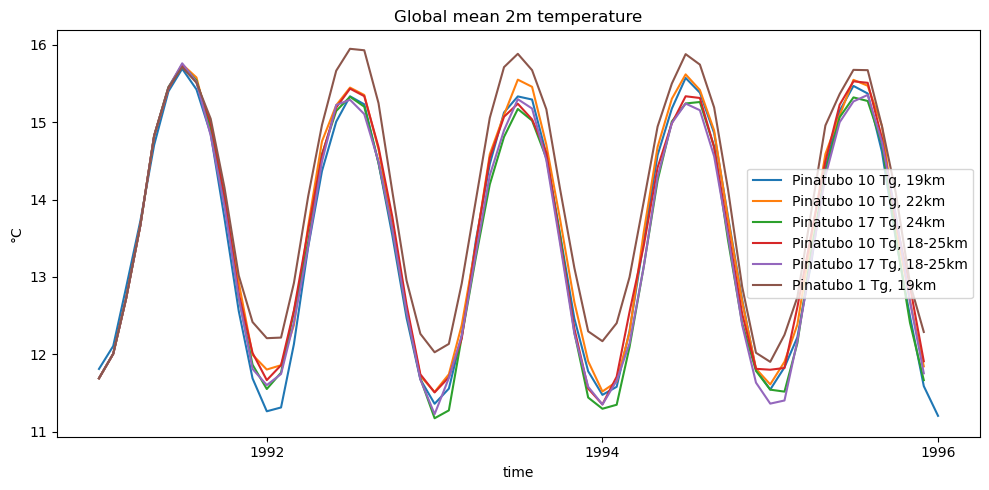

In [24]:
plt.figure(figsize=(10,5))

plt.plot(ts_19["time"], ts_19, label="Pinatubo 10 Tg, 19km")
plt.plot(ts_22["time"], ts_22, label="Pinatubo 10 Tg, 22km")
plt.plot(ts_24["time"], ts_24, label="Pinatubo 17 Tg, 24km")
plt.plot(ts_1825["time"], ts_1825, label="Pinatubo 10 Tg, 18-25km")
plt.plot(ts_1825_17tg["time"], ts_1825_17tg, label="Pinatubo 17 Tg, 18-25km")
plt.plot(ts_1tg["time"], ts_1tg, label="Pinatubo 1 Tg, 19km")

plt.xlabel("time")
plt.ylabel("°C")
plt.legend()
plt.title("Global mean 2m temperature")
plt.tight_layout()
plt.show()

In [25]:
def anomalies(da, base_monthly):
    return da.groupby("time.month") - base_monthly

In [26]:
a_19 = anomalies(ts_19, base)
a_22 = anomalies(ts_22, base)
a_24 = anomalies(ts_24, base)
a_1825 = anomalies(ts_1825, base)
a_1825_17tg = anomalies(ts_1825_17tg, base)
a_1tg = anomalies(ts_1tg, base)

a_19 = global_mean(a_19)
a_22 = global_mean(a_22)
a_24 = global_mean(a_24)
a_1825 = global_mean(a_1825)
a_1825_17tg = global_mean(a_1825_17tg)
a_1tg = global_mean(a_1tg)

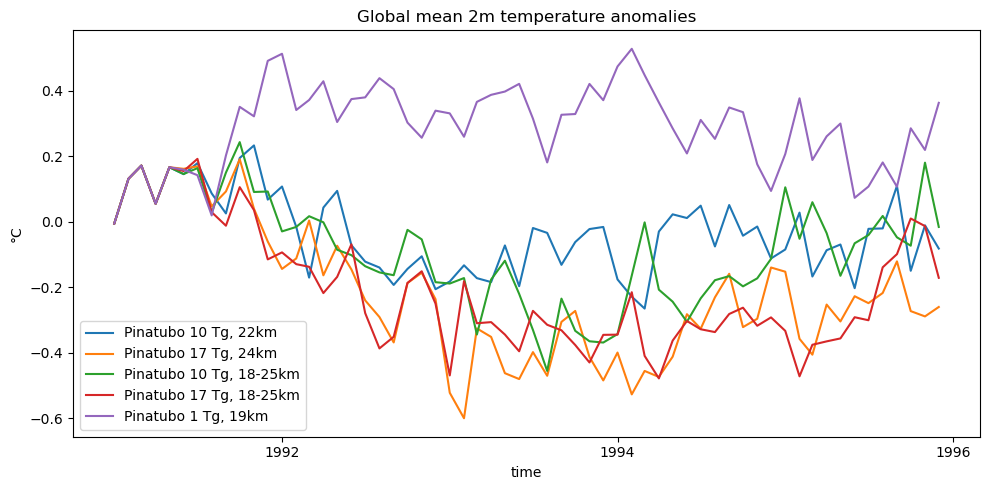

In [27]:
plt.figure(figsize=(10,5))

#plt.plot(a_19["time"], a_19, label="Pinatubo 10 Tg, 19km")
plt.plot(a_22["time"], a_22, label="Pinatubo 10 Tg, 22km")
plt.plot(a_24["time"], a_24, label="Pinatubo 17 Tg, 24km")
plt.plot(a_1825["time"], a_1825, label="Pinatubo 10 Tg, 18-25km")
plt.plot(a_1825_17tg["time"], a_1825_17tg, label="Pinatubo 17 Tg, 18-25km")
plt.plot(a_1tg["time"], a_1tg, label="Pinatubo 1 Tg, 19km")

plt.xlabel("time")
plt.ylabel("°C")
plt.legend()
plt.title("Global mean 2m temperature anomalies")
plt.tight_layout()
plt.show()

<>:22: SyntaxWarning: invalid escape sequence '\%'
<>:22: SyntaxWarning: invalid escape sequence '\%'
/tmp/ipykernel_3152271/1281356185.py:22: SyntaxWarning: invalid escape sequence '\%'
  plt.plot(o3_1pr.time, o3_1pr, color="hotpink", label = "Pinatubo only: 10Tg SO2, with 1$\%$ as SO4, 19km")


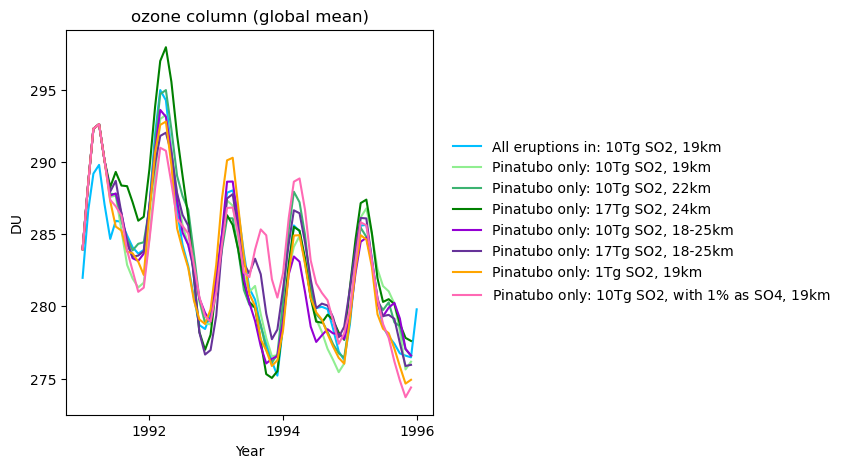

In [32]:
DU = 1.0 / 2.1415e-05
cb_o3 = "cb_O3"

o3 = ds_19[cb_o3].weighted(weighted_lat).mean(dim=["lat", "lon"]) * DU
o3 = o3.sel(time=slice('1991-01-01', '1996-01-01'))
o3_22 = ds_22[cb_o3].weighted(weighted_lat_22).mean(dim=["lat", "lon"]) * DU
o3_19_c = ds_19_c[cb_o3].weighted(weighted_lat_19_c).mean(dim=["lat", "lon"]) * DU
o3_24 = ds_24[cb_o3].weighted(weighted_lat_24).mean(dim=["lat", "lon"]) * DU
o3_1825 = ds_1825[cb_o3].weighted(weighted_lat_1825).mean(dim=["lat", "lon"]) * DU
o3_1825_17tg = ds_1825_17tg[cb_o3].weighted(weighted_lat_1825_17tg).mean(dim=["lat", "lon"]) * DU
o3_1tg = ds_1tg[cb_o3].weighted(weighted_lat_1tg).mean(dim=["lat", "lon"]) * DU
o3_1pr = ds_1pr[cb_o3].weighted(weighted_lat_1pr).mean(dim=["lat", "lon"]) * DU

plt.figure(figsize=(7, 5))
plt.plot(o3.time, o3, color = "deepskyblue", label = "All eruptions in: 10Tg SO2, 19km")
plt.plot(o3_19_c.time, o3_19_c, color = "lightgreen", label = "Pinatubo only: 10Tg SO2, 19km")
plt.plot(o3_22.time, o3_22, color = "mediumseagreen", label = "Pinatubo only: 10Tg SO2, 22km")
plt.plot(o3_24.time, o3_24, color = "green", label = "Pinatubo only: 17Tg SO2, 24km")
plt.plot(o3_1825.time, o3_1825, color="darkviolet", label = "Pinatubo only: 10Tg SO2, 18-25km")
plt.plot(o3_1825_17tg.time, o3_1825_17tg, color="rebeccapurple", label = "Pinatubo only: 17Tg SO2, 18-25km")
plt.plot(o3_1tg.time, o3_1tg, color="orange", label = "Pinatubo only: 1Tg SO2, 19km")
plt.plot(o3_1pr.time, o3_1pr, color="hotpink", label = "Pinatubo only: 10Tg SO2, with 1$\%$ as SO4, 19km")
plt.xlabel("Year")
plt.ylabel("DU")
plt.title("ozone column (global mean)")
fig = plt.gcf()
ax = plt.gca()

fig.subplots_adjust(right=0.65)

ax.legend(
    loc="center left",
    bbox_to_anchor=(1.02, 0.5),
    frameon=False
)

plt.show()

In [40]:
oh_19 = ds_19["OH"].weighted(weighted_lat).mean(dim=["lev", "lat", "lon"])
oh_19 = oh_19.sel(time=slice("1991-01", "1996-01"))
oh_19_c = ds_19_c["OH"].weighted(weighted_lat_19_c).mean(dim=["lev", "lat", "lon"])
oh_22 = ds_22["OH"].weighted(weighted_lat_22).mean(dim=["lev", "lat", "lon"])
oh_24 = ds_24["OH"].weighted(weighted_lat_24).mean(dim=["lev", "lat", "lon"])
oh_1825 = ds_1825["OH"].weighted(weighted_lat_1825).mean(dim=["lev", "lat", "lon"])
oh_1825_17tg = ds_1825_17tg["OH"].weighted(weighted_lat_1825_17tg).mean(dim=["lev", "lat", "lon"])
oh_1tg = ds_1tg["OH"].weighted(weighted_lat_1tg).mean(dim=["lev", "lat", "lon"])
oh_1pr = ds_1pr["OH"].weighted(weighted_lat_1pr).mean(dim=["lev", "lat", "lon"])


<>:9: SyntaxWarning: invalid escape sequence '\%'
<>:9: SyntaxWarning: invalid escape sequence '\%'
/tmp/ipykernel_3152271/4124703221.py:9: SyntaxWarning: invalid escape sequence '\%'
  plt.plot(oh_1pr.time, oh_1pr, color="hotpink", label = "Pinatubo only: 10Tg SO2, with 1$\%$ as SO4, 19km")


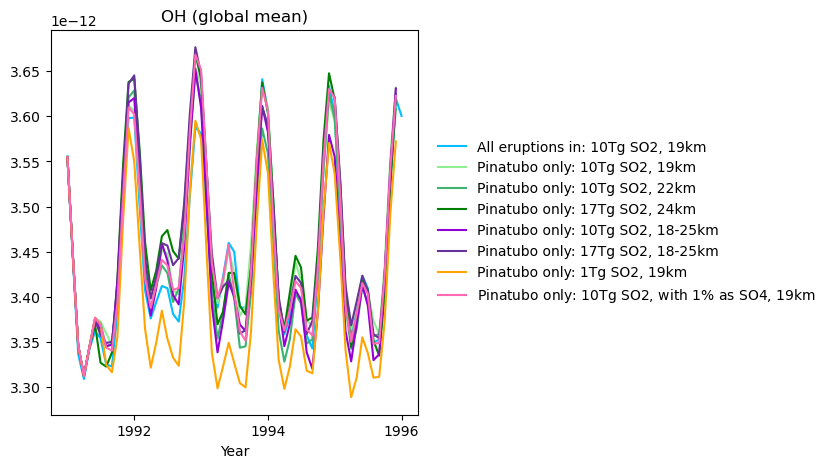

In [41]:
plt.figure(figsize=(7, 5))
plt.plot(oh_19.time, oh_19, color = "deepskyblue", label = "All eruptions in: 10Tg SO2, 19km")
plt.plot(oh_19_c.time, oh_19_c, color = "lightgreen", label = "Pinatubo only: 10Tg SO2, 19km")
plt.plot(oh_22.time, oh_22, color = "mediumseagreen", label = "Pinatubo only: 10Tg SO2, 22km")
plt.plot(oh_24.time, oh_24, color = "green", label = "Pinatubo only: 17Tg SO2, 24km")
plt.plot(oh_1825.time, oh_1825, color="darkviolet", label = "Pinatubo only: 10Tg SO2, 18-25km")
plt.plot(oh_1825_17tg.time, oh_1825_17tg, color="rebeccapurple", label = "Pinatubo only: 17Tg SO2, 18-25km")
plt.plot(oh_1tg.time, oh_1tg, color="orange", label = "Pinatubo only: 1Tg SO2, 19km")
plt.plot(oh_1pr.time, oh_1pr, color="hotpink", label = "Pinatubo only: 10Tg SO2, with 1% as SO4, 19km")
plt.xlabel("Year")
plt.title("OH (global mean)")
fig = plt.gcf()
ax = plt.gca()

fig.subplots_adjust(right=0.65)

ax.legend(
    loc="center left",
    bbox_to_anchor=(1.02, 0.5),
    frameon=False
)

plt.show()